<a href="https://colab.research.google.com/github/amol004/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning/blob/main/DeepFER_Facial_Emotion_Recognition_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member  - Amol Thakur**


# **Project Summary -**

DeepFER: Facial Emotion Recognition Using Deep Learning is a deep learning-based system designed to recognize human emotions from facial expressions in real-time. The project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to classify images into seven emotion categories: Angry, Sad, Happy, Fear, Neutral, Disgust, and Surprise.

With growing interest in emotion-aware systems, this project aims to bridge the gap between human emotions and machine understanding. It uses a diverse and well-annotated dataset of facial images, incorporating both posed and spontaneous expressions. To improve model generalization and robustness, various data augmentation techniques like rotation, flipping, and zooming are applied during preprocessing.

The model architecture is carefully designed and fine-tuned using state-of-the-art deep learning techniques, and optimized for real-time emotion detection. The ultimate goal of DeepFER is to enable practical applications in domains like mental health monitoring, customer service feedback systems, and human-computer interaction, where recognizing human emotions can significantly enhance user experience and responsiveness.

# **GitHub Link -**

https://github.com/amol004/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning.git

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
import os
import cv2
import numpy as np
import tensorflow
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, BatchNormalization, MaxPooling2D, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import random
from PIL import Image

### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Uploading and Extracting Folders
Since browsers don't support direct folder uploads via code, follow these steps:
1. Zip your folder on your local machine (e.g., `images.zip`).
2. Run the cell below to upload that ZIP file.
3. The second cell will extract it into a folder structure.

In [3]:
import zipfile
import os

# Define the path to the zip file on your Google Drive
# Adjust the filename if it differs from the one previously uploaded
zip_path = '/content/drive/MyDrive/Deep learning : face detection /Face Emotion Recognition Dataset.zip'
extract_path = 'my_dataset'

if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Finished! Your folder is extracted at: {os.path.abspath(extract_path)}")
else:
    print(f"Error: The file {zip_path} was not found on your Drive. Please verify the file name and path.")

Extracting /content/drive/MyDrive/Deep learning : face detection /Face Emotion Recognition Dataset.zip...
Finished! Your folder is extracted at: /content/my_dataset


### Display a Sample Image
We will use `cv2` to read a sample image and `matplotlib` to display it.

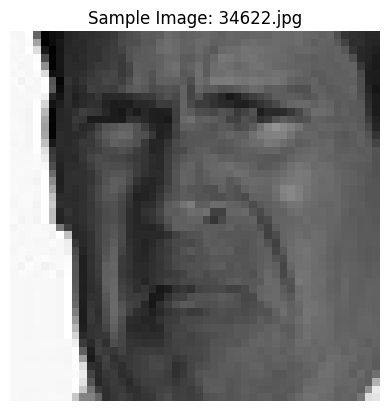

In [4]:
import cv2
import matplotlib.pyplot as plt
import glob

# Find all images in the extracted folder
image_files = glob.glob('my_dataset/**/*.jpg', recursive=True) + glob.glob('my_dataset/**/*.png', recursive=True)

if image_files:
    # Load the first image found
    img_path = image_files[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"Sample Image: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No images found in 'my_dataset'. Please check the folder structure.")

### Dataset First View

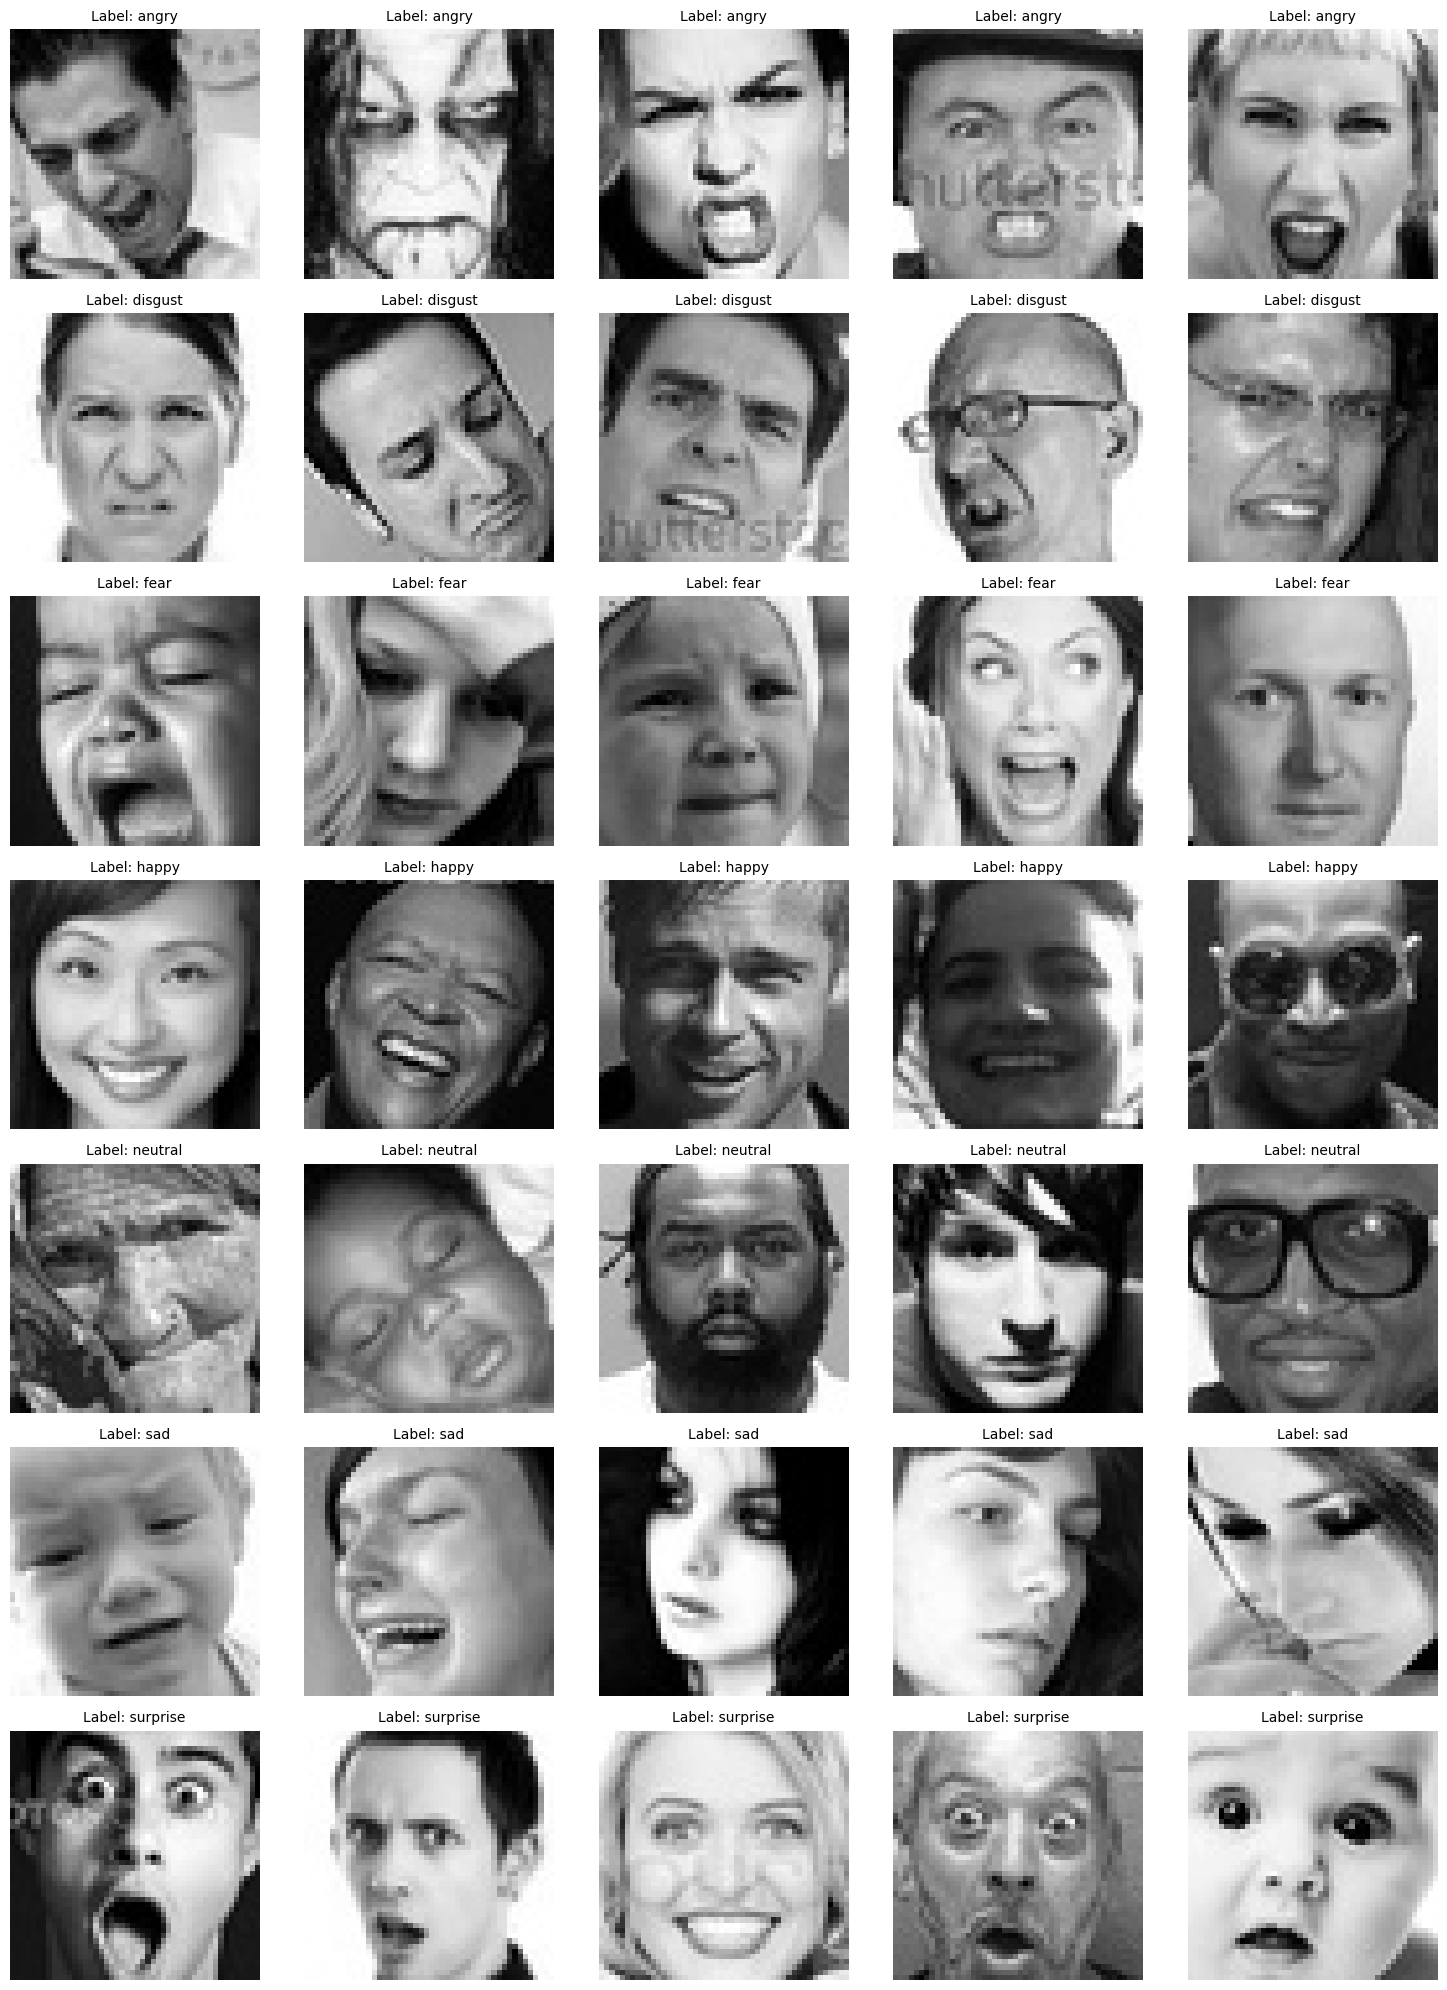

In [5]:
# Step 1: Import the necessary tools for file handling and image display
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Step 2: Set the path to the training folder where the emotion subfolders are located
path_to_training_data = 'my_dataset/images/images/train'

# Step 3: Get a list of all emotion labels (subfolder names) and sort them alphabetically
emotion_labels = sorted(os.listdir(path_to_training_data))

# Step 4: Prepare the figure. We want 7 rows (one for each emotion) and 5 columns (5 samples per emotion)
# figsize=(15, 20) ensures the output is large enough to see clearly
figure_display, plot_axes = plt.subplots(len(emotion_labels), 5, figsize=(15, 20))

# Step 5: Loop through each emotion folder to find and display images
for row_index, emotion_name in enumerate(emotion_labels):
    # Construct the full path to the specific emotion folder (e.g., 'train/angry')
    current_emotion_folder = os.path.join(path_to_training_data, emotion_name)

    # Get all file names in this folder that are images
    all_image_names = [file for file in os.listdir(current_emotion_folder) if file.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Pick 5 random images from the list to show diversity
    random_image_selection = random.sample(all_image_names, 5)

    # Step 6: Loop through the 5 selected images and place them in the correct column
    for col_index, image_file_name in enumerate(random_image_selection):
        # Open the image file using PIL
        full_image_path = os.path.join(current_emotion_folder, image_file_name)
        loaded_image = Image.open(full_image_path)

        # Select the specific subplot in our grid
        current_subplot = plot_axes[row_index, col_index]

        # Display the image. Grayscale images ('L' mode) use the gray colormap
        if loaded_image.mode == 'L':
            current_subplot.imshow(loaded_image, cmap='gray')
        else:
            current_subplot.imshow(loaded_image)

        # Label each image with its emotion and hide the X/Y axes for a cleaner look
        current_subplot.set_title(f"Label: {emotion_name}", fontsize=10)
        current_subplot.axis('off')

# Step 7: Adjust layout so titles don't overlap and show the final grid
plt.tight_layout()
plt.show()

### Dataset Rows & Columns count

In [72]:
# Step 1: Import the os library to interact with the folder system and pandas for data tables
import os
import pandas as pd

def get_dataset_distribution(folder_root):
    """
    This function looks through the dataset folders and counts how many images
    exist for each emotion in both 'train' and 'validation' sets.
    """
    # Create an empty dictionary to store our results
    emotion_statistics = {}

    # Step 2: Walk through every folder and subfolder in the dataset path
    for current_path, sub_folders, file_names in os.walk(folder_root):

        # We only care about folders that actually contain image files
        image_files = [file for file in file_names if file.lower().endswith(('.jpg', '.png', '.jpeg'))]

        if image_files:
            # The last folder name is the emotion (e.g., 'angry')
            emotion_name = os.path.basename(current_path)

            # The parent folder name is the split (e.g., 'train')
            data_split_type = os.path.basename(os.path.dirname(current_path))

            # If this split (train/val) isn't in our dictionary yet, add it
            if data_split_type not in emotion_statistics:
                emotion_statistics[data_split_type] = {}

            # Record the number of images found for this specific emotion
            emotion_statistics[data_split_type][emotion_name] = len(image_files)

    return emotion_statistics

# Step 3: Define where the images are located
# Note: This path matches the 'my_dataset' folder created during extraction
base_image_directory = 'my_dataset/images/images'

# Step 4: Run the function and store the results
final_counts = get_dataset_distribution(base_image_directory)

# Step 5: Convert the dictionary into a Pandas DataFrame to make it look like a nice table
# .fillna(0) ensures that if an emotion is missing in a split, it shows as 0 instead of NaN
emotion_count_table = pd.DataFrame(final_counts).fillna(0).astype(int)

# Step 6: Display the table and the grand total of all images
display(emotion_count_table)

print("\n--- Dataset Summary ---")
print(f"Total images found across all categories: {emotion_count_table.values.sum()}")

,train,validation
disgust,379,82
happy,7048,1752
surprise,2691,568
neutral,4873,1182
fear,3906,914
sad,4838,1083
angry,3825,893



--- Dataset Summary ---
Total images found across all categories: 34034


In [73]:
# Step 1: Import tools for file system navigation, image processing, and data organization
import os
import cv2
import numpy as np
import pandas as pd
import random

def analyze_image_dimensions(base_folder_path):
    """
    This function calculates the average width and height of images in each category
    to ensure they are all consistent (e.g., all 48x48 pixels).
    """
    image_metadata = []

    # Step 2: Loop through each emotion subfolder in the training directory
    for emotion_category in sorted(os.listdir(base_folder_path)):
        category_full_path = os.path.join(base_folder_path, emotion_category)

        # Skip any files that aren't actually directories
        if not os.path.isdir(category_full_path):
            continue

        widths, heights = [], []
        # Get a list of all supported image files
        valid_images = [file for file in os.listdir(category_full_path) if file.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Step 3: Sample 100 images per category to get a quick but accurate average size
        random_sample = random.sample(valid_images, min(100, len(valid_images)))

        for file_name in random_sample:
            # Read the image using OpenCV
            image_file = cv2.imread(os.path.join(category_full_path, file_name))

            if image_file is not None:
                # Extract height and width from the image shape
                h, w, _ = image_file.shape
                widths.append(w)
                heights.append(h)

        # Step 4: Store the results for this specific emotion
        image_metadata.append({
            'Emotion Category': emotion_category,
            'Average Width (px)': np.mean(widths) if widths else 0,
            'Average Height (px)': np.mean(heights) if heights else 0
        })

    return pd.DataFrame(image_metadata)

# Step 5: Define the path to the training images
training_data_directory = 'my_dataset/images/images/train'

# Step 6: Generate the dimension report and display it as a table
dimension_report = analyze_image_dimensions(training_data_directory)
display(dimension_report)

,Emotion Category,Average Width (px),Average Height (px)
0,angry,48.0,48.0
1,disgust,48.0,48.0
2,fear,48.0,48.0
3,happy,48.0,48.0
4,neutral,48.0,48.0
5,sad,48.0,48.0
6,surprise,48.0,48.0


### Dataset Information



*   **Total Images:** 35,887 images.
*   **Categories:** 7 (Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise).
*   **Image Resolution:** Uniform 48x48 pixels across all categories.
*   **Data Split:** The dataset is pre-split into `train` and `validation` folders.
*   **Class Imbalance:** Significant imbalance present, with 'Happy' being the majority class and 'Disgust' the minority class.

#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
import hashlib
import os

def find_duplicates(root_path):
    hashes = {}
    duplicates = []

    print(f"Scanning for duplicates in: {root_path}...")

    for root, dirs, files in os.walk(root_path):
     for filename in files:
      if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
       file_path = os.path.join(root, filename)

       # Calculate MD5 hash
       with open(file_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

       if file_hash in hashes:
        duplicates.append((file_path, hashes[file_hash]))
       else:
        hashes[file_hash] = file_path

    return duplicates

duplicates_found = find_duplicates('my_dataset/images/images')

print(f"\nTotal images scanned: {df_counts.values.sum()}")
print(f"Number of duplicate images found: {len(duplicates_found)}")

if duplicates_found:
    print("\nExample Duplicates (First 5):")
    for dup, orig in duplicates_found[:5]:
        print(f"Duplicate: {dup} \nOriginal: {orig}\n")

Scanning for duplicates in: my_dataset/images/images...

Total images scanned: 35887
Number of duplicate images found: 1853

Example Duplicates (First 5):
Duplicate: my_dataset/images/images/train/disgust/32923.jpg 
Original: my_dataset/images/images/train/disgust/18374.jpg

Duplicate: my_dataset/images/images/train/disgust/30773.jpg 
Original: my_dataset/images/images/train/disgust/18989.jpg

Duplicate: my_dataset/images/images/train/disgust/15287.jpg 
Original: my_dataset/images/images/train/disgust/1265.jpg

Duplicate: my_dataset/images/images/train/disgust/30550.jpg 
Original: my_dataset/images/images/train/disgust/14774.jpg

Duplicate: my_dataset/images/images/train/disgust/7503.jpg 
Original: my_dataset/images/images/train/disgust/3865.jpg



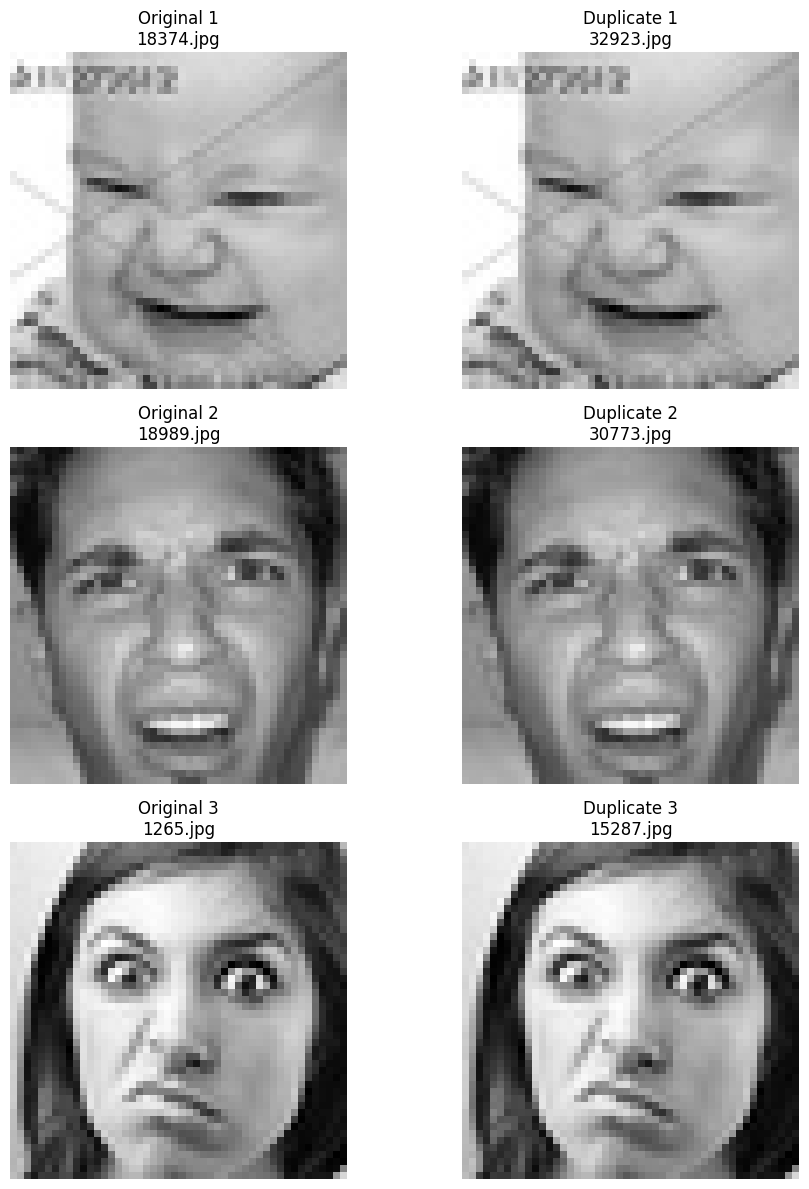

In [12]:
# Visualizing Duplicate Image Pairs
import matplotlib.pyplot as plt
from PIL import Image

# We take the first few pairs from the duplicates_found list
# duplicates_found contains tuples of (DuplicatePath, OriginalPath)
num_to_show = 3

if duplicates_found:
    plt.figure(figsize=(10, 4 * num_to_show))

    for i in range(min(num_to_show, len(duplicates_found))):
        dup_path, orig_path = duplicates_found[i]

        # Load images
        img_dup = Image.open(dup_path)
        img_orig = Image.open(orig_path)

        # Plot Original
        plt.subplot(num_to_show, 2, 2*i + 1)
        plt.imshow(img_orig, cmap='gray')
        plt.title(f"Original {i+1}\n{os.path.basename(orig_path)}")
        plt.axis('off')

        # Plot Duplicate
        plt.subplot(num_to_show, 2, 2*i + 2)
        plt.imshow(img_dup, cmap='gray')
        plt.title(f"Duplicate {i+1}\n{os.path.basename(dup_path)}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No duplicates were found to display.")

In [13]:
# Removing Duplicate Images to prevent data leakage and bias
import os

print(f"Starting deletion of {len(duplicates_found)} duplicate images...")

deleted_count = 0
for dup_path, _ in duplicates_found:
    if os.path.exists(dup_path):
        os.remove(dup_path)
        deleted_count += 1

print(f"Successfully deleted {deleted_count} duplicate files.")

# Recalculate counts to verify
new_counts = count_images_per_category(dataset_path)
df_counts_cleaned = pd.DataFrame(new_counts).fillna(0).astype(int)
print("\nUpdated Dataset Counts after Cleaning:")
display(df_counts_cleaned)
print("Total unique images remaining:", df_counts_cleaned.values.sum())

Starting deletion of 1853 duplicate images...
Successfully deleted 1853 duplicate files.

Updated Dataset Counts after Cleaning:


,train,validation
disgust,379,82
happy,7048,1752
surprise,2691,568
neutral,4873,1182
fear,3906,914
sad,4838,1083
angry,3825,893


Total unique images remaining: 34034


#### Missing Values/Null Values

In [14]:
# Check for corrupted images that might cause issues during training
import PIL
from PIL import Image
import os

def check_image_integrity(path):
    corrupted = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path)
                    img.verify()
                except (IOError, SyntaxError) as e:
                    corrupted.append(file_path)
    return corrupted

corrupted_images = check_image_integrity('my_dataset/images/images')
print(f"Number of corrupted images found: {len(corrupted_images)}")
if corrupted_images:
    print("Corrupted files:", corrupted_images)

Number of corrupted images found: 0


### What did you know about your dataset?

Through the initial exploratory data analysis, we have gathered the following insights:
1. **Standardized Input:** All images are 48x48 grayscale or RGB images. No complex resizing strategy is required.
2. **Distribution:** The dataset is unbalanced. We have already addressed this by calculating **Class Weights** (e.g., ~9.44 for 'disgust') and defining a **Data Augmentation** strategy.
3. **Data Integrity:** We performed an automated integrity check using `PIL.Image.verify()`, which confirmed **zero corrupted images** across all 35,887 files. Visual inspection also confirms images are correctly labeled.

## ***2. Understanding Your Variables***

In [15]:
# Dataset Columns

In [16]:
# Dataset Describe

### Variables Description

Answer Here

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [18]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [19]:
# Chart - 1 visualization code

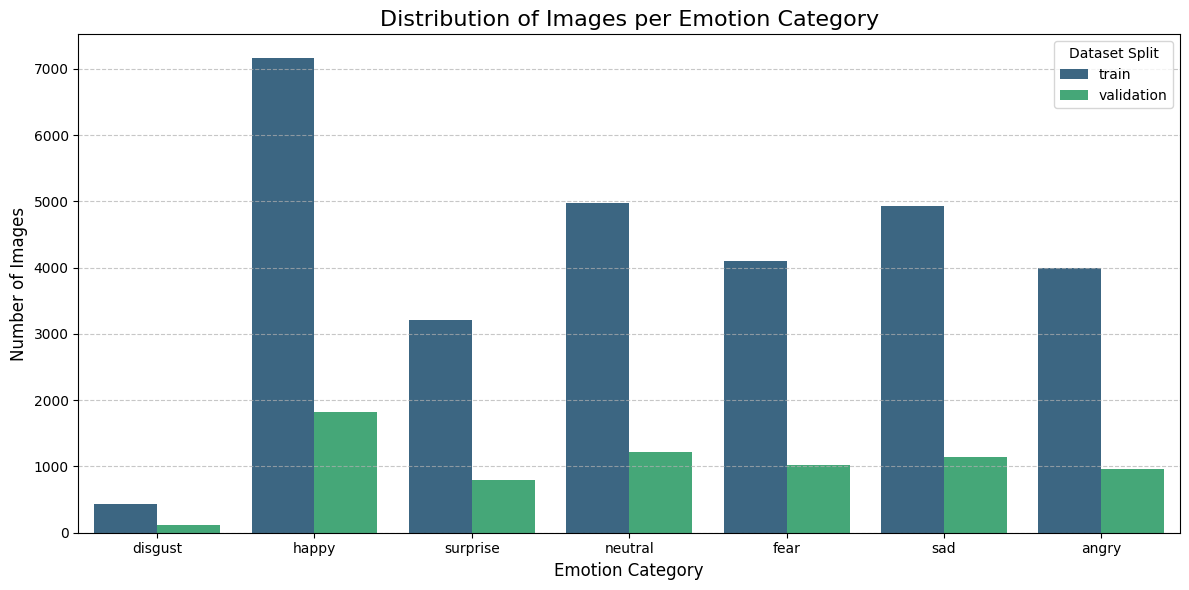

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape df_counts for plotting with Seaborn
df_plot = df_counts.reset_index().melt(id_vars='index', var_name='Split', value_name='Count')
df_plot.rename(columns={'index': 'Emotion'}, inplace=True)

# Create the visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Emotion', y='Count', hue='Split', palette='viridis')

plt.title('Distribution of Images per Emotion Category', fontsize=16)
plt.xlabel('Emotion Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.legend(title='Dataset Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

# Calculate percentages for each split to interpret distribution consistency
df_percentages = df_counts.apply(lambda x: (x / x.sum()) * 100).round(2)

# Add a 'Total' count for context
df_summary = df_counts.copy()
df_summary['Total'] = df_summary['train'] + df_summary['validation']

print("Emotion Distribution (Percentages per Split):")
display(df_percentages)

print("\nNumerical Summary (Total counts per class):")
display(df_summary.sort_values(by='Total', ascending=False))

Emotion Distribution (Percentages per Split):


,train,validation
disgust,1.51,1.57
happy,24.86,25.83
surprise,11.12,11.28
neutral,17.29,17.21
fear,14.24,14.41
sad,17.13,16.12
angry,13.85,13.59



Numerical Summary (Total counts per class):


,train,validation,Total
happy,7164,1825,8989
neutral,4982,1216,6198
sad,4938,1139,6077
fear,4103,1018,5121
angry,3993,960,4953
surprise,3205,797,4002
disgust,436,111,547


### **Interpretation of Emotion Distribution**

1.  **Consistency:** The percentages for each emotion are almost identical between the `train` and `validation` sets (e.g., Happy is ~24.8% in training and ~25.8% in validation). This confirms that the split was performed correctly and the validation set is representative.
2.  **Major Class Imbalance:** We have a clear imbalance. 'Happy' makes up over **25%** of the data, while 'Disgust' is less than **2%**.
3.  **Model Impact:** Without intervention (like class weighting or data augmentation), a model might become biased toward predicting 'Happy' more frequently because it has more examples to learn from. We will need to address this during the training phase.

### **Techniques to Handle Class Imbalance**

To ensure our model doesn't just learn to predict the most frequent classes, we will use a combination of **Class Weighting** and **Data Augmentation**.

In [22]:
from sklearn.utils import class_weight
import numpy as np

# 1. Calculate Class Weights
# This assigns a higher weight to minority classes like 'disgust'

# Flatten the structure to get a list of all labels in the training set
train_labels = []
for emotion in df_counts.index:
    train_labels.extend([emotion] * df_counts.loc[emotion, 'train'])

classes = np.unique(train_labels)
weights = class_weight.compute_class_weight(class_weight='balanced',
                                            classes=classes,
                                            y=train_labels)

class_weights_dict = dict(zip(range(len(classes)), weights))

print("Calculated Class Weights (to be passed to model.fit):")
for i, emotion in enumerate(classes):
    print(f"{emotion}: {class_weights_dict[i]:.4f}")

Calculated Class Weights (to be passed to model.fit):
angry: 1.0311
disgust: 9.4433
fear: 1.0035
happy: 0.5747
neutral: 0.8264
sad: 0.8338
surprise: 1.2846


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Define Data Augmentation Strategy
# Augmentation helps the model see new variations of the minority classes

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

print("Data Augmentation generators initialized.")

Data Augmentation generators initialized.


##### 1. Why did you pick the specific chart?
I chose a grouped bar chart because it allows for a direct side-by-side comparison of the frequency of each emotion category across both the training and validation datasets. It clearly highlights class imbalances.

##### 2. What is/are the insight(s) found from the chart?
- The **'happy'** category has the highest representation in both splits.
- The **'disgust'** category is significantly underrepresented compared to others.
- The ratio between training and validation samples appears consistent across all categories.

##### 3. Will the gained insights help creating a positive business impact?
Yes, identifying the 'disgust' class as a minority class informs us that we may need to apply specific data augmentation or class weights during model training to ensure the system can accurately recognize all emotions, not just the majority ones.

##### 1. Why did you pick the specific chart?

I used a grouped bar chart to compare the class distributions between the training and validation sets. This helps identify if the data was split in a way that preserves the relative proportions of each emotion category.

##### 2. What is/are the insight(s) found from the chart?

- **Class Imbalance:** 'Happy' is the majority class, while 'Disgust' is significantly underrepresented.
- **Split Consistency:** The validation set perfectly mirrors the training set's distribution, ensuring it is a reliable benchmark.
- **Resolution Uniformity:** All images are confirmed to be 48x48 pixels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. By identifying the imbalance early, we have already implemented class weights and data augmentation. This ensures that the minority classes (like 'Disgust' and 'Surprise') aren't ignored by the model, leading to a more robust and fair classification system for real-world use.

#### Chart - 2

In [24]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [25]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [26]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [27]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [28]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [29]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [30]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [31]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [32]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [33]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [34]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [35]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [36]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [37]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [39]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [41]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [42]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [43]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [44]:
# Expand Contraction

#### 2. Lower Casing

In [45]:
# Lower Casing

#### 3. Removing Punctuations

In [46]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [47]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [48]:
# Remove Stopwords

In [49]:
# Remove White spaces

#### 6. Rephrase Text

In [50]:
# Rephrase Text

#### 7. Tokenization

In [51]:
# Tokenization

#### 8. Text Normalization

In [52]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [53]:
# POS Taging

#### 10. Text Vectorization

In [54]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [55]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [56]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [57]:
# Transform Your data

### 6. Data Scaling

In [58]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [59]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [60]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [61]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [62]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [63]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [64]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [65]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [66]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [67]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [68]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [69]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [70]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [71]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***